Top 20 Picks: ['SNDK', 'VICR', 'LITE', 'VSCO', 'HL', 'ALB', 'ARWR', 'MU', 'WDC', 'COHR', 'FTRE', 'FORM', 'AA', 'TER', 'KALU', 'AEO', 'LCII', 'SATS', 'AMKR', 'OMCL']


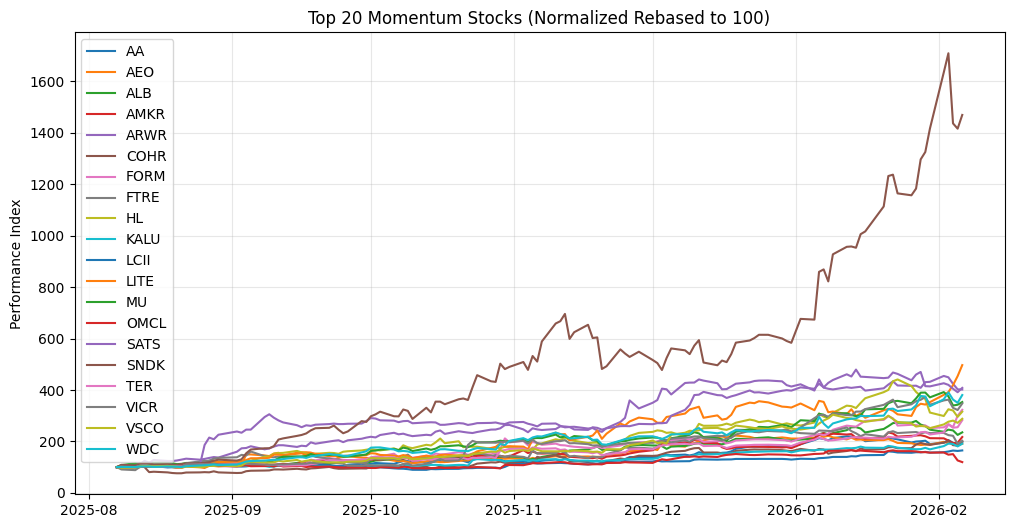

In [ ]:
import sys
import os
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Make sure we import the strategy code from your repo's src folder
SRC_PATH = os.path.abspath("../../../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import strategies.momentum.clenow_trend as clenow_trend
importlib.reload(clenow_trend)  # picks up the latest edits without restarting the kernel

# Defaults from the strategy
TOP_N = getattr(clenow_trend, "DEFAULT_TOP_N", 20)
UNIVERSE_FILE = "../../../universe.csv"

# ========== 1. Regime Filter ==========
print("=" * 60)
print("STEP 1: REGIME FILTER (SPY / IJH / IJR breadth)")
print("=" * 60)
regime_on = clenow_trend.check_regime()
print(f"Regime is: {'✅ RISK-ON' if regime_on else '🛑 RISK-OFF (no new buys)'}\n")

# Show the ETF prices vs their 200-day SMA
etf_data = yf.download(list(clenow_trend.REGIME_ETFS), period="1y", group_by="ticker", progress=False, threads=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, etf in zip(axes, clenow_trend.REGIME_ETFS):
    close = etf_data[etf]["Close"].dropna()
    sma200 = close.rolling(clenow_trend.REGIME_SMA_PERIOD).mean()
    ax.plot(close.index, close, label="Close")
    ax.plot(sma200.index, sma200, label="200-SMA", linestyle="--", color="orange")
    above = float(close.iloc[-1]) > float(sma200.dropna().iloc[-1]) if len(sma200.dropna()) > 0 else False
    ax.set_title(f"{etf} {'✅' if above else '❌'}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Regime Filter: ETFs vs 200-day SMA", fontweight="bold")
plt.tight_layout()
plt.show()

# ========== 2. Score Universe (with entry filter) ==========
print("=" * 60)
print("STEP 2+3: SCORE UNIVERSE (entry filter: price > 200 SMA) & RANK")
print("=" * 60)
scores_df = clenow_trend.score_universe(universe_file=UNIVERSE_FILE)
print(f"Scored {len(scores_df)} stocks (passed 200-SMA entry filter)")
print(f"\nTop {TOP_N} picks:")
print(scores_df.head(TOP_N).to_string(index=False))

picks = scores_df.head(TOP_N)["Symbol"].tolist()

# ========== 3. Normalized price chart for top picks ==========
if picks:
    data = yf.download(picks, period="6mo", progress=False)["Close"]
    normalized = (data / data.iloc[0]) * 100

    plt.figure(figsize=(12, 6))
    for col in normalized.columns:
        plt.plot(normalized.index, normalized[col], label=col)
    plt.title(f"Top {len(picks)} Momentum Stocks (Normalized Rebased to 100)")
    plt.ylabel("Performance Index")
    plt.legend(ncol=4, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

Scored 1389 symbols. Showing top 10 by score:
  Symbol        Score
0   SNDK  4868.006497
1   VICR  2166.275866
2   LITE  1942.762574
3   VSCO  1131.128944
4     HL   917.894689
5    ALB   855.161105
6   ARWR   836.299777
7     MU   815.490702
8    WDC   781.696092
9   COHR   593.621788


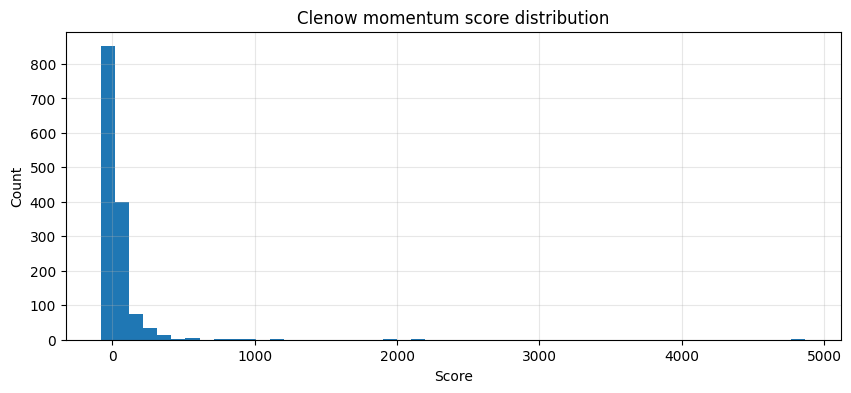

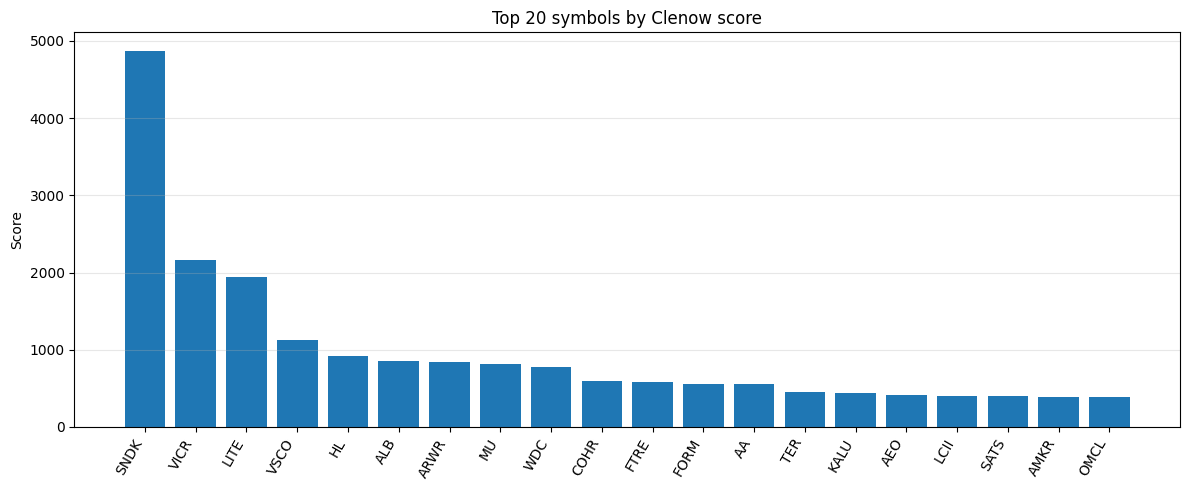

In [ ]:
# ========== 4. Inverse-Volatility Sizing ==========
print("=" * 60)
print("STEP 4: INVERSE-VOLATILITY SIZING (min 2%, max 10%)")
print("=" * 60)

top = scores_df.head(TOP_N).copy()
weights = clenow_trend._inverse_vol_weights(top.set_index("Symbol")["Vol20"])

sizing_df = top[["Symbol", "Score", "Close", "Vol20"]].copy()
sizing_df = sizing_df.set_index("Symbol")
sizing_df["Weight"] = weights
sizing_df["Weight_Pct"] = sizing_df["Weight"] * 100

EXAMPLE_BUDGET = 10_000
sizing_df["Notional"] = sizing_df["Weight"] * EXAMPLE_BUDGET

print(f"\nSizing for ${EXAMPLE_BUDGET:,.0f} budget:")
print(sizing_df[["Score", "Vol20", "Weight_Pct", "Notional"]].to_string(float_format="%.2f"))
print(f"\nTotal weight: {sizing_df['Weight'].sum():.4f}")
print(f"Total notional: ${sizing_df['Notional'].sum():,.2f}")

# Bar chart: weight per symbol
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.bar(sizing_df.index, sizing_df["Weight_Pct"], color="steelblue")
ax1.axhline(clenow_trend.MIN_WEIGHT * 100, color="red", linestyle="--", label=f"Min {clenow_trend.MIN_WEIGHT*100:.0f}%")
ax1.axhline(clenow_trend.MAX_WEIGHT * 100, color="red", linestyle="--", label=f"Max {clenow_trend.MAX_WEIGHT*100:.0f}%")
ax1.set_title("Inverse-Vol Weight per Symbol")
ax1.set_ylabel("Weight (%)")
ax1.tick_params(axis="x", rotation=60)
ax1.legend()
ax1.grid(True, axis="y", alpha=0.3)

ax2 = axes[1]
ax2.bar(sizing_df.index, sizing_df["Vol20"] * 100, color="coral")
ax2.set_title("20-Day Annualized Volatility")
ax2.set_ylabel("Volatility (%)")
ax2.tick_params(axis="x", rotation=60)
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ========== Score distribution ==========
print("\n" + "=" * 60)
print("SCORE DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(scores_df["Score"].values, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Clenow momentum score distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

# Top-N bar chart
bar_df = scores_df.head(TOP_N)
axes[1].bar(bar_df["Symbol"], bar_df["Score"], color="steelblue")
axes[1].set_title(f"Top {TOP_N} symbols by Clenow score")
axes[1].tick_params(axis="x", rotation=60)
axes[1].set_ylabel("Score")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

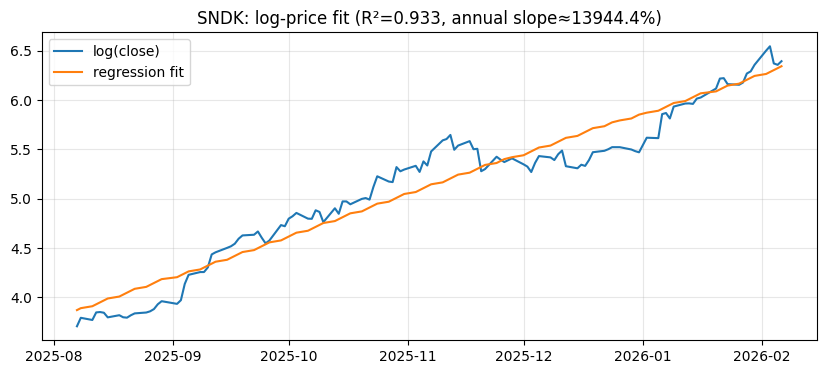

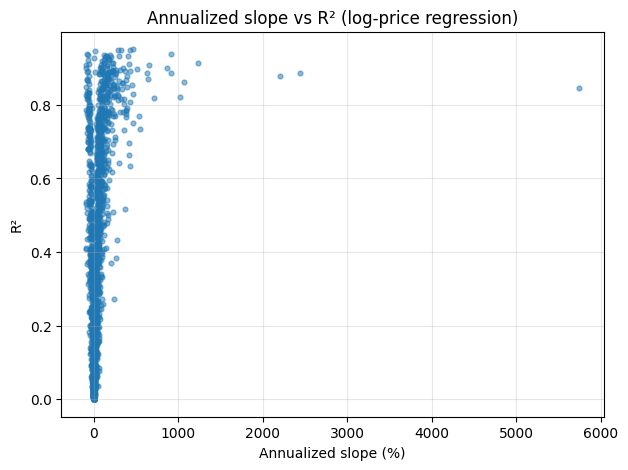

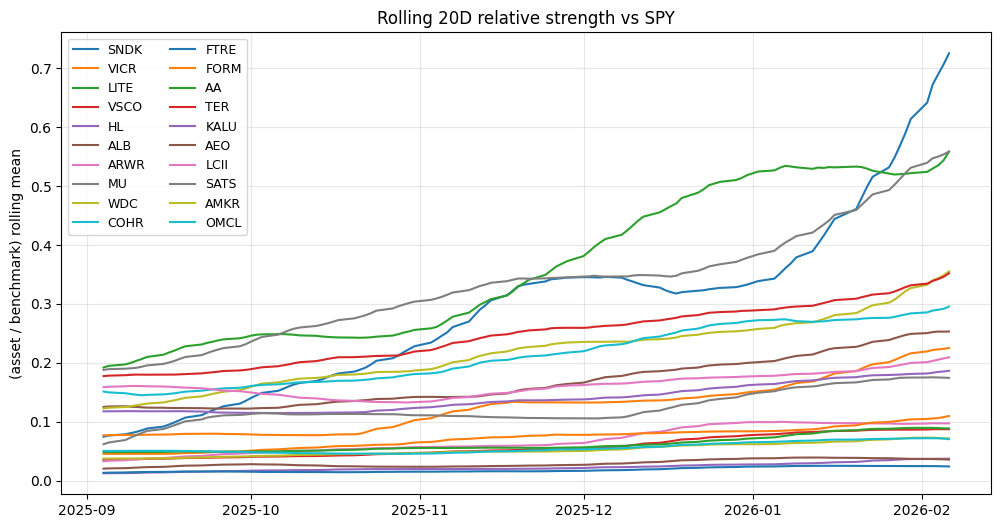

In [ ]:
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import linregress

# ========== 5. Exit Logic Analysis ==========
print("=" * 60)
print("STEP 5: EXIT LOGIC (Rank > 30 OR Price < 100-SMA)")
print("=" * 60)

# Simulate: pretend the top 40 stocks are "held" and see which would be exited
simulated_held = set(scores_df.head(40)["Symbol"].tolist())
exit_candidates = scores_df[scores_df["Symbol"].isin(simulated_held)].copy()

exit_candidates["Would_Exit"] = False
exit_candidates["Exit_Reason"] = ""

for idx, row in exit_candidates.iterrows():
    reasons = []
    if row["Rank"] > clenow_trend.EXIT_RANK_CUTOFF:
        reasons.append(f"rank_{int(row['Rank'])}_gt_{clenow_trend.EXIT_RANK_CUTOFF}")
    if row["Close"] < row["SMA100"]:
        reasons.append("below_100sma")
    if reasons:
        exit_candidates.at[idx, "Would_Exit"] = True
        exit_candidates.at[idx, "Exit_Reason"] = " + ".join(reasons)

n_exit = exit_candidates["Would_Exit"].sum()
n_hold = len(exit_candidates) - n_exit
print(f"\nIf holding top 40 stocks: {n_hold} HOLD, {n_exit} EXIT")
if n_exit > 0:
    print("\nWould EXIT:")
    print(exit_candidates[exit_candidates["Would_Exit"]][["Symbol", "Rank", "Close", "SMA100", "Exit_Reason"]].to_string(index=False))

# Visualize: scatter of rank vs price/SMA100 ratio
if not exit_candidates.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    for _, row in exit_candidates.iterrows():
        color = "red" if row["Would_Exit"] else "green"
        marker = "x" if row["Would_Exit"] else "o"
        ax.scatter(row["Rank"], row["Close"] / row["SMA100"], color=color, marker=marker, s=40)
        if row["Would_Exit"]:
            ax.annotate(row["Symbol"], (row["Rank"], row["Close"] / row["SMA100"]),
                        fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")

    ax.axvline(clenow_trend.EXIT_RANK_CUTOFF, color="red", linestyle="--", alpha=0.5, label=f"Rank cutoff ({clenow_trend.EXIT_RANK_CUTOFF})")
    ax.axhline(1.0, color="orange", linestyle="--", alpha=0.5, label="Price = 100-SMA")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Price / 100-SMA")
    ax.set_title("Exit Logic: Rank vs Price/100-SMA ratio")
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Green = hold, Red X = exit
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=8, label="HOLD"),
        Line2D([0], [0], marker="x", color="red", markersize=8, label="EXIT"),
    ]
    ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][:2], loc="upper right")
    plt.tight_layout()
    plt.show()


# ========== Deeper Dive: Regression Fit & Relative Strength ==========
print("\n" + "=" * 60)
print("DEEPER DIVE: LOG REGRESSION & RELATIVE STRENGTH")
print("=" * 60)


@dataclass
class RegressionStats:
    slope: float
    r2: float
    annualized_slope_pct: float


def _close_series(symbol: str, period: str) -> pd.Series:
    """Download close prices and always return a 1D Series."""
    df = yf.download(symbol, period=period, progress=False)
    if isinstance(df, pd.DataFrame) and "Close" in df.columns:
        close = df["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        return close.dropna()
    return pd.Series(dtype=float)


def regression_stats_from_prices(close_prices: pd.Series) -> Optional[RegressionStats]:
    close_prices = close_prices.dropna()
    if len(close_prices) < 30:
        return None
    y = np.log(close_prices.values.astype(float))
    x = np.arange(len(y), dtype=float)
    slope, _, r_value, _, _ = linregress(x, y)
    r2 = float(r_value) ** 2
    annualized_slope_pct = (np.exp(slope) ** 252 - 1) * 100
    return RegressionStats(slope=float(slope), r2=r2, annualized_slope_pct=float(annualized_slope_pct))


def plot_log_regression_fit(symbol: str, period: str = "1y") -> None:
    close = _close_series(symbol, period)
    stats = regression_stats_from_prices(close)
    if stats is None:
        print(f"Not enough data for {symbol}.")
        return
    y = np.log(close.values.astype(float))
    x = np.arange(len(y), dtype=float)
    intercept = y.mean() - stats.slope * x.mean()
    y_fit = stats.slope * x + intercept

    plt.figure(figsize=(10, 4))
    plt.plot(close.index, y, label="log(close)")
    plt.plot(close.index, y_fit, label="regression fit")
    plt.title(f"{symbol}: log-price fit (R²={stats.r2:.3f}, annual slope≈{stats.annualized_slope_pct:.1f}%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_slope_vs_r2(scores_df: pd.DataFrame, period: str = "1y") -> None:
    syms = scores_df["Symbol"].astype(str).tolist()
    rows = []
    for s in syms:
        close = _close_series(s, period)
        close = close.iloc[-90:] if len(close) >= 90 else close
        st = regression_stats_from_prices(close)
        if st is None:
            continue
        rows.append({"Symbol": s, "SlopePct": st.annualized_slope_pct, "R2": st.r2})

    df = pd.DataFrame(rows)
    if df.empty:
        print("No points to plot.")
        return

    plt.figure(figsize=(7, 5))
    plt.scatter(df["SlopePct"], df["R2"], s=12, alpha=0.5)
    plt.title("Annualized slope vs R² (log-price regression)")
    plt.xlabel("Annualized slope (%)")
    plt.ylabel("R²")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_rolling_relative_strength(picks, benchmark="SPY", window=20, period="6mo"):
    symbols = list(dict.fromkeys(picks + [benchmark]))
    close = yf.download(symbols, period=period, progress=False)["Close"]
    if isinstance(close, pd.Series):
        print("Not enough data.")
        return
    close = close.dropna(how="all")
    if benchmark not in close.columns:
        print(f"Benchmark {benchmark} not found.")
        return

    bench = close[benchmark].dropna()
    plt.figure(figsize=(12, 6))
    for s in picks:
        if s not in close.columns:
            continue
        series = close[s].dropna()
        aligned = pd.concat([series, bench], axis=1, join="inner")
        if aligned.empty:
            continue
        aligned.columns = ["asset", "bench"]
        rs = (aligned["asset"] / aligned["bench"]).rolling(window).mean()
        plt.plot(rs.index, rs.values, label=s)

    plt.title(f"Rolling {window}D relative strength vs {benchmark}")
    plt.ylabel("(asset / benchmark) rolling mean")
    plt.legend(ncol=2, fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.show()


# --- Run the deeper dive ---
CHOSEN_SYMBOL = picks[0] if picks else "AAPL"
plot_log_regression_fit(CHOSEN_SYMBOL)
plot_slope_vs_r2(scores_df)
plot_rolling_relative_strength(picks, benchmark="SPY", window=20)